# FreshRAG Reranking Stage Analysis
## Does Cross-Encoder Reranking Mitigate or Amplify Staleness Contamination?

This notebook analyzes the reranking stage (Stage 3b) results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

Reranker: `cross-encoder/ms-marco-MiniLM-L6-v2`

Metrics analyzed:
- Mean rank shift of relevant documents
- Reranker inference time & total latency
- Semantic ambiguity score
- Precision@k and stale intrusion before vs. after reranking
- Breakdown by time-sensitivity and domain

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

print('Setup complete.')

Setup complete.


In [5]:
# ── Load data ──
RESULTS_PATH = '../freshrag_experiment/results/rerank_results_aggregated.json'
DETAILED_PATH = '../freshrag_experiment/results/rerank_results_detailed.jsonl'

with open(RESULTS_PATH) as f:
    data = json.load(f)

# Load detailed results for per-query analysis
detailed = []
with open(DETAILED_PATH) as f:
    for line in f:
        if line.strip():
            detailed.append(json.loads(line))

df_detailed = pd.DataFrame(detailed)

print(f'Sections: {list(data.keys())}')
print(f'Conditions: {list(data["overall"].keys())}')
print(f'Queries per condition: {data["overall"]["fresh"]["n"]}')
print(f'Total detailed records: {len(df_detailed)}')

Sections: ['overall', 'by_time_sensitivity', 'by_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Total detailed records: 1156


## 1. Overall Reranking Impact
Does the cross-encoder improve or worsen retrieval quality as staleness increases?

In [6]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Mean Rank Shift': d['mean_rank_shift_mean'],
        'Semantic Ambiguity': d['semantic_ambiguity_score_mean'],
        'Inference Time (ms)': d['inference_time_ms_mean'],
        'Total Rerank Latency (ms)': d['total_rerank_latency_ms_mean'],
        'Retrieval Latency (ms)': d['retrieval_latency_ms_mean'],
        'Precision@k (before)': d['original_precision_at_k_mean'],
        'Precision@k (after)': d['reranked_precision_at_k_mean'],
        'Stale Intrusion (before)': d['original_stale_intrusion_rate_mean'],
        'Stale Intrusion (after)': d['reranked_stale_intrusion_rate_mean'],
        'Relevant Promoted': d['relevant_promoted_mean'],
        'Relevant Demoted': d['relevant_demoted_mean'],
        'Stale Promoted': d['stale_promoted_mean'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Mean Rank Shift': '{:+.4f}',
    'Semantic Ambiguity': '{:.4f}',
    'Inference Time (ms)': '{:.2f}',
    'Total Rerank Latency (ms)': '{:.2f}',
    'Retrieval Latency (ms)': '{:.2f}',
    'Precision@k (before)': '{:.4f}',
    'Precision@k (after)': '{:.4f}',
    'Stale Intrusion (before)': '{:.4f}',
    'Stale Intrusion (after)': '{:.4f}',
    'Relevant Promoted': '{:.2f}',
    'Relevant Demoted': '{:.2f}',
    'Stale Promoted': '{:.2f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Stale Intrusion (after)', 'Stale Promoted'])

,Staleness %,Mean Rank Shift,Semantic Ambiguity,Inference Time (ms),Total Rerank Latency (ms),Retrieval Latency (ms),Precision@k (before),Precision@k (after),Stale Intrusion (before),Stale Intrusion (after),Relevant Promoted,Relevant Demoted,Stale Promoted
Condition,,,,,,,,,,,,,
Fresh (0%),0,-0.1701,3.1058,133.35,133.39,36.70,0.2401,0.2401,0.0000,0.0000,0.37,0.26,0.00
Stale 10%,10,-0.1586,3.1164,109.47,109.50,13.00,0.2401,0.2401,0.0242,0.0242,0.35,0.25,0.02
Stale 30%,30,-0.1422,3.1506,112.45,112.48,13.12,0.2367,0.2367,0.1010,0.1010,0.34,0.23,0.08
Stale 50%,50,-0.1370,3.1547,106.47,106.50,14.20,0.2367,0.2367,0.1543,0.1543,0.33,0.23,0.14


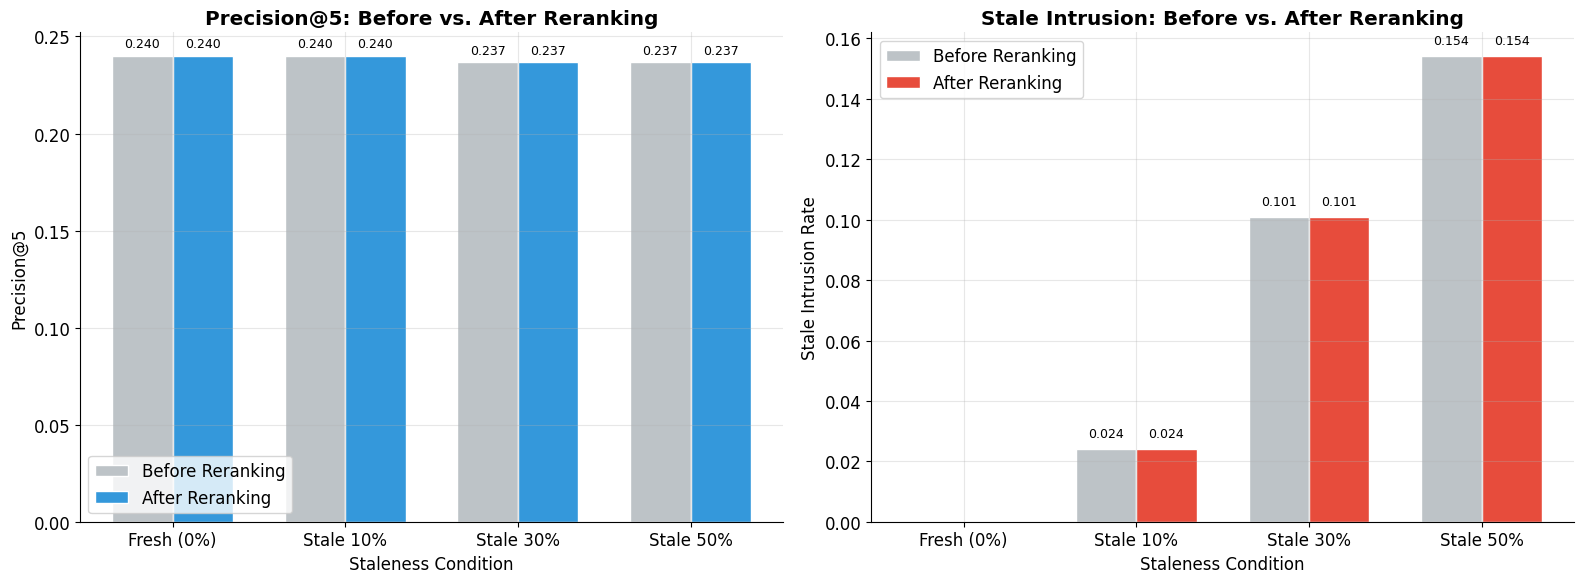

Saved: figures/fig8_rerank_before_after.png


In [7]:
# ── Fig 1: Precision Before vs. After Reranking ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision comparison
ax = axes[0]
prec_before = [data['overall'][c]['original_precision_at_k_mean'] for c in CONDITIONS]
prec_after = [data['overall'][c]['reranked_precision_at_k_mean'] for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
width = 0.35
bars1 = ax.bar(x - width/2, prec_before, width, label='Before Reranking', color='#bdc3c7', edgecolor='white')
bars2 = ax.bar(x + width/2, prec_after, width, label='After Reranking', color='#3498db', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Precision@5')
ax.set_title('Precision@5: Before vs. After Reranking', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Stale intrusion comparison
ax = axes[1]
intr_before = [data['overall'][c]['original_stale_intrusion_rate_mean'] for c in CONDITIONS]
intr_after = [data['overall'][c]['reranked_stale_intrusion_rate_mean'] for c in CONDITIONS]

bars1 = ax.bar(x - width/2, intr_before, width, label='Before Reranking', color='#bdc3c7', edgecolor='white')
bars2 = ax.bar(x + width/2, intr_after, width, label='After Reranking', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Stale Intrusion Rate')
ax.set_title('Stale Intrusion: Before vs. After Reranking', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
for bar in bars1:
    if bar.get_height() > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig8_rerank_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig8_rerank_before_after.png')

## 2. Mean Rank Shift of Relevant Documents
Does the reranker promote or demote answer-bearing docs? How does staleness affect this?

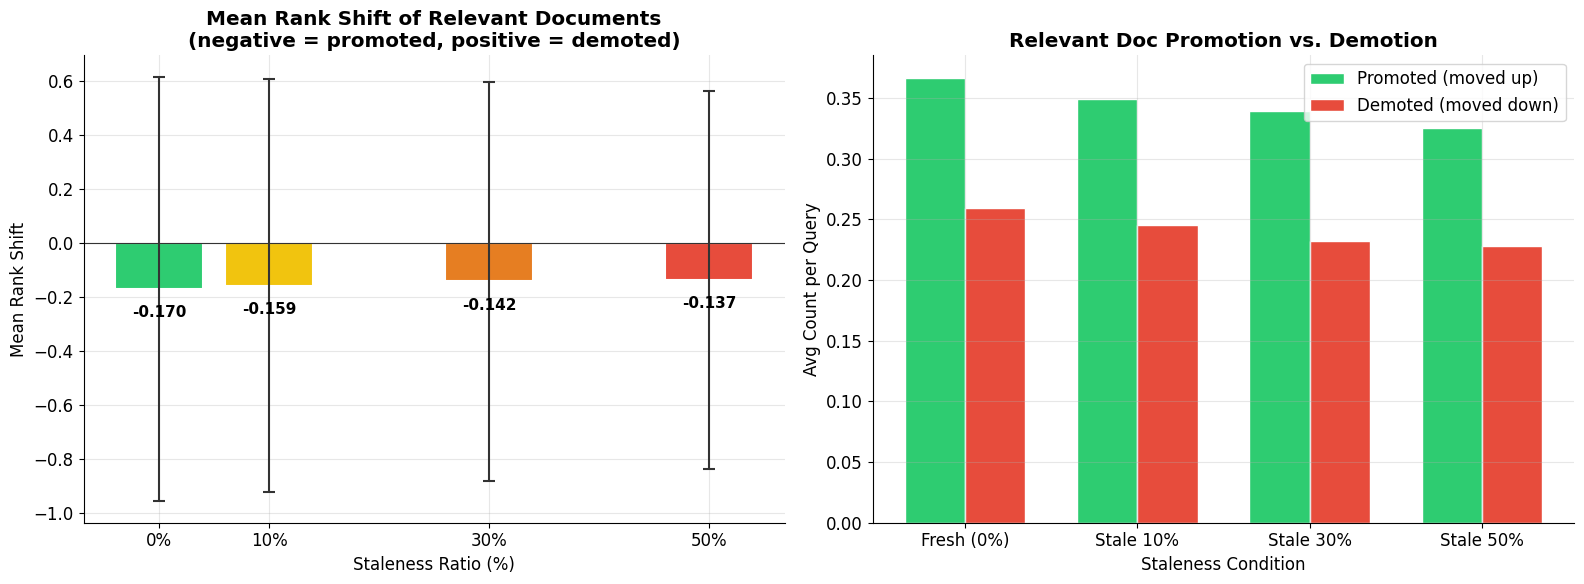

Saved: figures/fig9_rank_shift.png


In [8]:
# ── Fig 2: Mean Rank Shift ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of mean rank shift
ax = axes[0]
shifts = [data['overall'][c]['mean_rank_shift_mean'] for c in CONDITIONS]
shift_stds = [data['overall'][c]['mean_rank_shift_std'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, shifts, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, shifts, yerr=shift_stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.axhline(y=0, color='#333', linewidth=0.8, linestyle='-')
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Mean Rank Shift')
ax.set_title('Mean Rank Shift of Relevant Documents\n(negative = promoted, positive = demoted)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, shifts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.06,
            f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')

# Promoted vs. Demoted counts
ax = axes[1]
promoted = [data['overall'][c]['relevant_promoted_mean'] for c in CONDITIONS]
demoted = [data['overall'][c]['relevant_demoted_mean'] for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
width = 0.35
ax.bar(x - width/2, promoted, width, label='Promoted (moved up)', color='#2ecc71', edgecolor='white')
ax.bar(x + width/2, demoted, width, label='Demoted (moved down)', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Avg Count per Query')
ax.set_title('Relevant Doc Promotion vs. Demotion', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig9_rank_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig9_rank_shift.png')

## 3. Semantic Ambiguity Score
Low score spread = the reranker struggles to differentiate documents. Does staleness increase ambiguity?

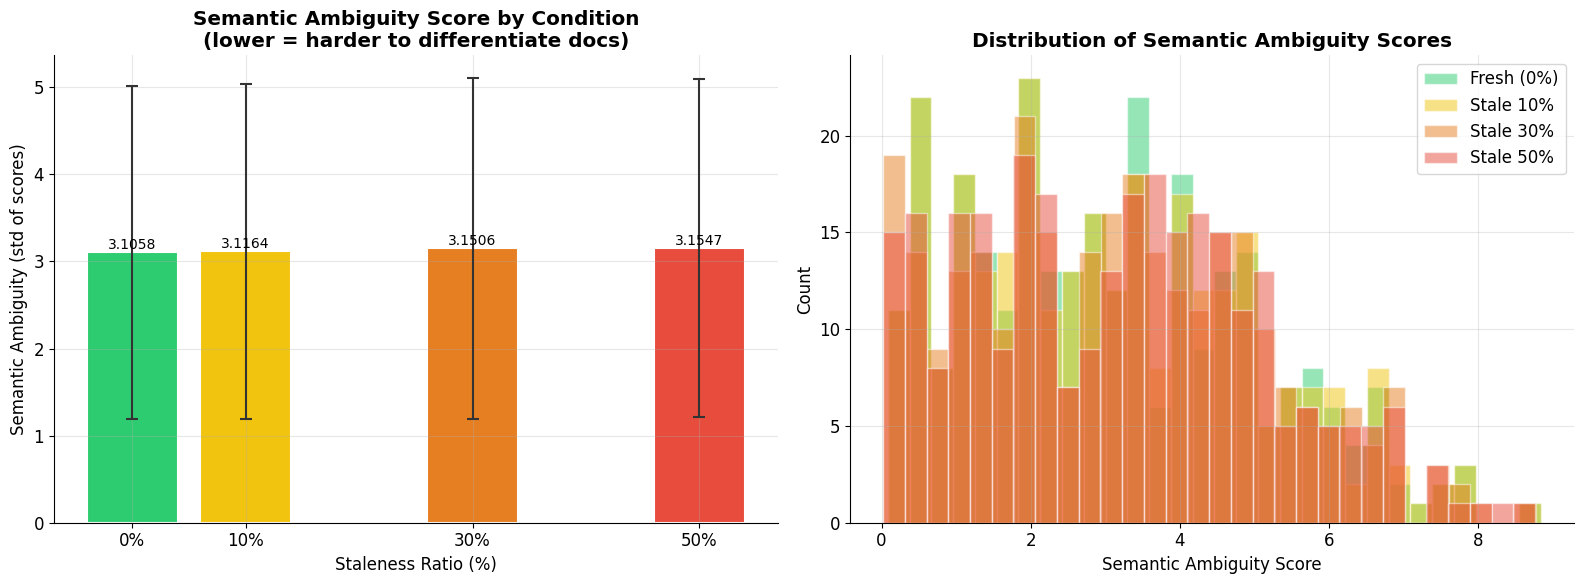

Saved: figures/fig10_semantic_ambiguity.png


In [9]:
# ── Fig 3: Semantic Ambiguity ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ambiguity by condition
ax = axes[0]
ambiguity = [data['overall'][c]['semantic_ambiguity_score_mean'] for c in CONDITIONS]
ambiguity_std = [data['overall'][c]['semantic_ambiguity_score_std'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, ambiguity, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, ambiguity, yerr=ambiguity_std, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Semantic Ambiguity (std of scores)')
ax.set_title('Semantic Ambiguity Score by Condition\n(lower = harder to differentiate docs)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, ambiguity):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Distribution of per-query ambiguity scores
ax = axes[1]
for cond in CONDITIONS:
    subset = df_detailed[df_detailed['condition'] == cond]['semantic_ambiguity_score']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Semantic Ambiguity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Semantic Ambiguity Scores', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig10_semantic_ambiguity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig10_semantic_ambiguity.png')

## 4. Latency Analysis
Reranking cost: cross-encoder inference time, total rerank latency, and comparison with retrieval latency.

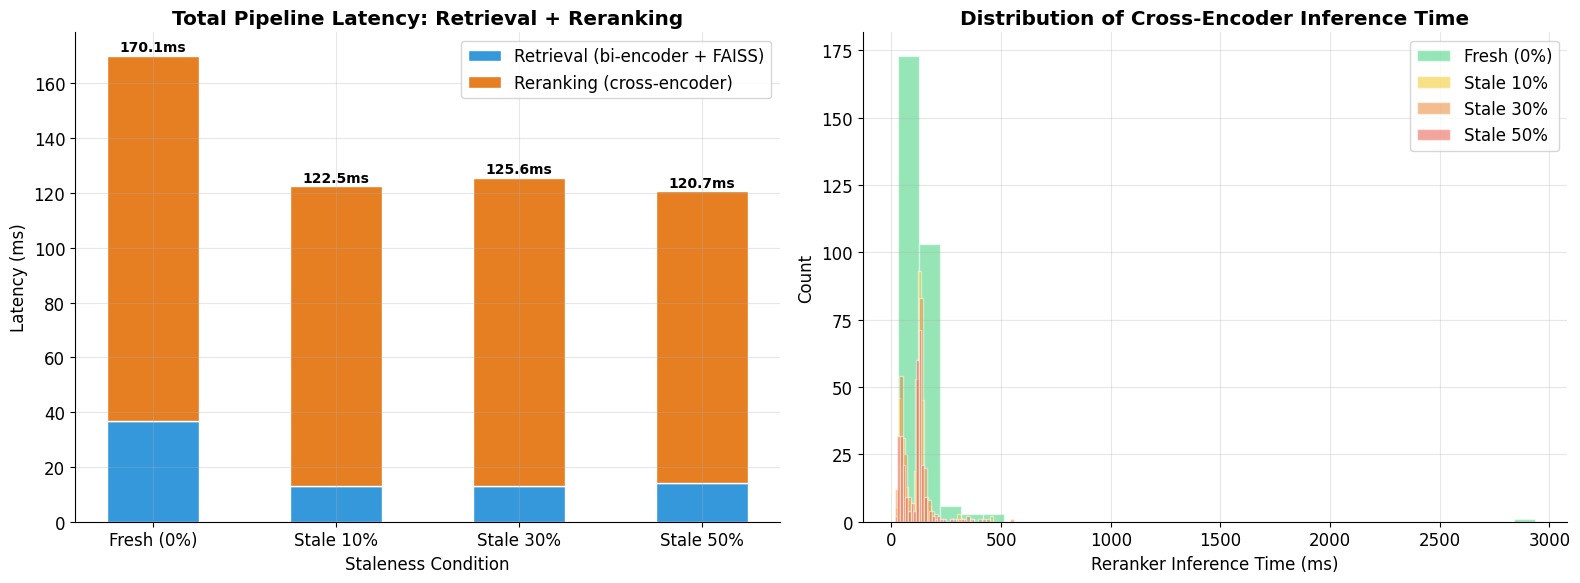

Saved: figures/fig11_rerank_latency.png


In [10]:
# ── Fig 4: Latency Breakdown ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: retrieval latency + rerank latency
ax = axes[0]
retrieval_lat = [data['overall'][c]['retrieval_latency_ms_mean'] for c in CONDITIONS]
rerank_lat = [data['overall'][c]['total_rerank_latency_ms_mean'] for c in CONDITIONS]

x = np.arange(len(CONDITIONS))
width = 0.5
bars1 = ax.bar(x, retrieval_lat, width, label='Retrieval (bi-encoder + FAISS)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x, rerank_lat, width, bottom=retrieval_lat, label='Reranking (cross-encoder)', color='#e67e22', edgecolor='white')

ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Latency (ms)')
ax.set_title('Total Pipeline Latency: Retrieval + Reranking', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

# Add total labels
for i, (r, rr) in enumerate(zip(retrieval_lat, rerank_lat)):
    ax.text(i, r + rr + 0.5, f'{r + rr:.1f}ms', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Inference time distribution
ax = axes[1]
for cond in CONDITIONS:
    subset = df_detailed[df_detailed['condition'] == cond]['inference_time_ms']
    ax.hist(subset, bins=30, alpha=0.5, label=CONDITION_LABELS[cond], color=COLORS[cond], edgecolor='white')
ax.set_xlabel('Reranker Inference Time (ms)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Cross-Encoder Inference Time', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig11_rerank_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig11_rerank_latency.png')

In [11]:
# ── Latency summary table ──
print('Latency Breakdown (mean per query):')
print(f'{"":<15} {"Retrieval":>12} {"Rerank Infer":>14} {"Rerank Total":>14} {"Pipeline":>12}')
print('-' * 70)
for cond in CONDITIONS:
    d = data['overall'][cond]
    ret_ms = d['retrieval_latency_ms_mean']
    inf_ms = d['inference_time_ms_mean']
    tot_ms = d['total_rerank_latency_ms_mean']
    pipe_ms = ret_ms + tot_ms
    print(f'{CONDITION_LABELS[cond]:<15} {ret_ms:>10.2f}ms {inf_ms:>12.2f}ms {tot_ms:>12.2f}ms {pipe_ms:>10.2f}ms')

print()
# Rerank overhead as % of total pipeline
print('Reranking as % of total pipeline latency:')
for cond in CONDITIONS:
    d = data['overall'][cond]
    ret_ms = d['retrieval_latency_ms_mean']
    tot_ms = d['total_rerank_latency_ms_mean']
    pct = tot_ms / (ret_ms + tot_ms) * 100 if (ret_ms + tot_ms) > 0 else 0
    print(f'  {CONDITION_LABELS[cond]}: {pct:.1f}%')

Latency Breakdown (mean per query):
                   Retrieval   Rerank Infer   Rerank Total     Pipeline
----------------------------------------------------------------------
Fresh (0%)           36.70ms       133.35ms       133.39ms     170.09ms
Stale 10%            13.00ms       109.47ms       109.50ms     122.50ms
Stale 30%            13.12ms       112.45ms       112.48ms     125.60ms
Stale 50%            14.20ms       106.47ms       106.50ms     120.70ms

Reranking as % of total pipeline latency:
  Fresh (0%): 78.4%
  Stale 10%: 89.4%
  Stale 30%: 89.6%
  Stale 50%: 88.2%


## 5. Time-Sensitive vs. Time-Insensitive Comparison
Does the reranker behave differently for time-sensitive queries under staleness?

In [12]:
# ── Build time-sensitivity dataframe ──
ts_rows = []
for cond in CONDITIONS:
    for ts_label, ts_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
        key = f'{cond}__{ts_key}'
        d = data['by_time_sensitivity'].get(key, {})
        if d:
            ts_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Query Type': ts_label,
                'Mean Rank Shift': d.get('mean_rank_shift_mean', 0),
                'Semantic Ambiguity': d.get('semantic_ambiguity_score_mean', 0),
                'Precision@k (after)': d.get('reranked_precision_at_k_mean', 0),
                'Stale Intrusion (after)': d.get('reranked_stale_intrusion_rate_mean', 0),
                'Stale Promoted': d.get('stale_promoted_mean', 0),
            })

df_ts = pd.DataFrame(ts_rows)
print(df_ts.to_string(index=False, float_format='{:.4f}'.format))

 Condition  Staleness %       Query Type  Mean Rank Shift  Semantic Ambiguity  Precision@k (after)  Stale Intrusion (after)  Stale Promoted
Fresh (0%)            0   Time-Sensitive          -0.1805              3.1879               0.2360                   0.0000          0.0000
Fresh (0%)            0 Time-Insensitive          -0.1606              3.0298               0.2440                   0.0000          0.0000
 Stale 10%           10   Time-Sensitive          -0.1709              3.1906               0.2360                   0.0417          0.0216
 Stale 10%           10 Time-Insensitive          -0.1472              3.0476               0.2440                   0.0080          0.0133
 Stale 30%           30   Time-Sensitive          -0.1403              3.2277               0.2288                   0.1439          0.1295
 Stale 30%           30 Time-Insensitive          -0.1439              3.0790               0.2440                   0.0613          0.0267
 Stale 50%          

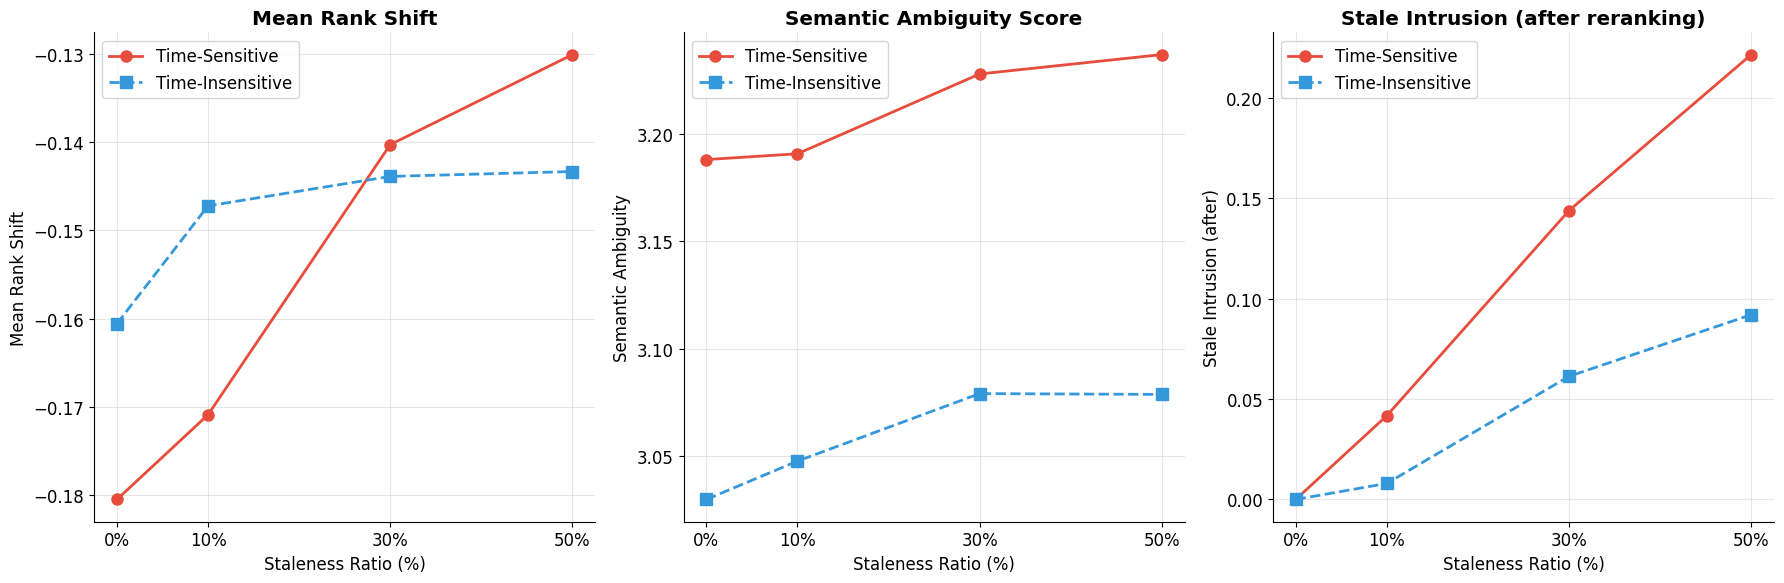

Saved: figures/fig12_rerank_time_sensitivity.png


In [13]:
# ── Fig 5: Time-sensitivity comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metric_configs = [
    ('Mean Rank Shift', 'Mean Rank Shift'),
    ('Semantic Ambiguity', 'Semantic Ambiguity Score'),
    ('Stale Intrusion (after)', 'Stale Intrusion (after reranking)'),
]

for ax, (col, title) in zip(axes, metric_configs):
    for qt, style in [('Time-Sensitive', '-o'), ('Time-Insensitive', '--s')]:
        subset = df_ts[df_ts['Query Type'] == qt]
        color = '#e74c3c' if qt == 'Time-Sensitive' else '#3498db'
        ax.plot(subset['Staleness %'], subset[col], style,
                label=qt, color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig12_rerank_time_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig12_rerank_time_sensitivity.png')

## 6. Domain-Level Analysis
Which domains benefit from or are harmed by reranking under staleness?

In [14]:
# ── Build domain dataframe ──
domain_rows = []
for cond in CONDITIONS:
    for domain in DOMAINS:
        key = f'{cond}__{domain}'
        d = data['by_domain'].get(key, {})
        if d:
            domain_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Domain': DOMAIN_LABELS.get(domain, domain),
                'domain_key': domain,
                'Mean Rank Shift': d.get('mean_rank_shift_mean', 0),
                'Semantic Ambiguity': d.get('semantic_ambiguity_score_mean', 0),
                'Precision@k (after)': d.get('reranked_precision_at_k_mean', 0),
                'Stale Intrusion (after)': d.get('reranked_stale_intrusion_rate_mean', 0),
                'Stale Promoted': d.get('stale_promoted_mean', 0),
                'n': d.get('n', 0),
            })

df_domain = pd.DataFrame(domain_rows)

# Pivot: rank shift by domain x condition
pivot = df_domain.pivot_table(index='Domain', columns='Condition', values='Mean Rank Shift')
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Mean Rank Shift by Domain × Condition:')
print(pivot.to_string(float_format='{:+.4f}'.format))

Mean Rank Shift by Domain × Condition:
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain     +0.0043    +0.0101    -0.0014    -0.0158
Finance                 -0.2500    -0.2500    -0.2250    -0.2083
Healthcare              -0.4468    -0.4296    -0.3966    -0.3534
Legal                   -0.0909    -0.0727    -0.0364    -0.0727
SaaS/IT                 -0.0603    -0.0431    -0.0431    -0.0287


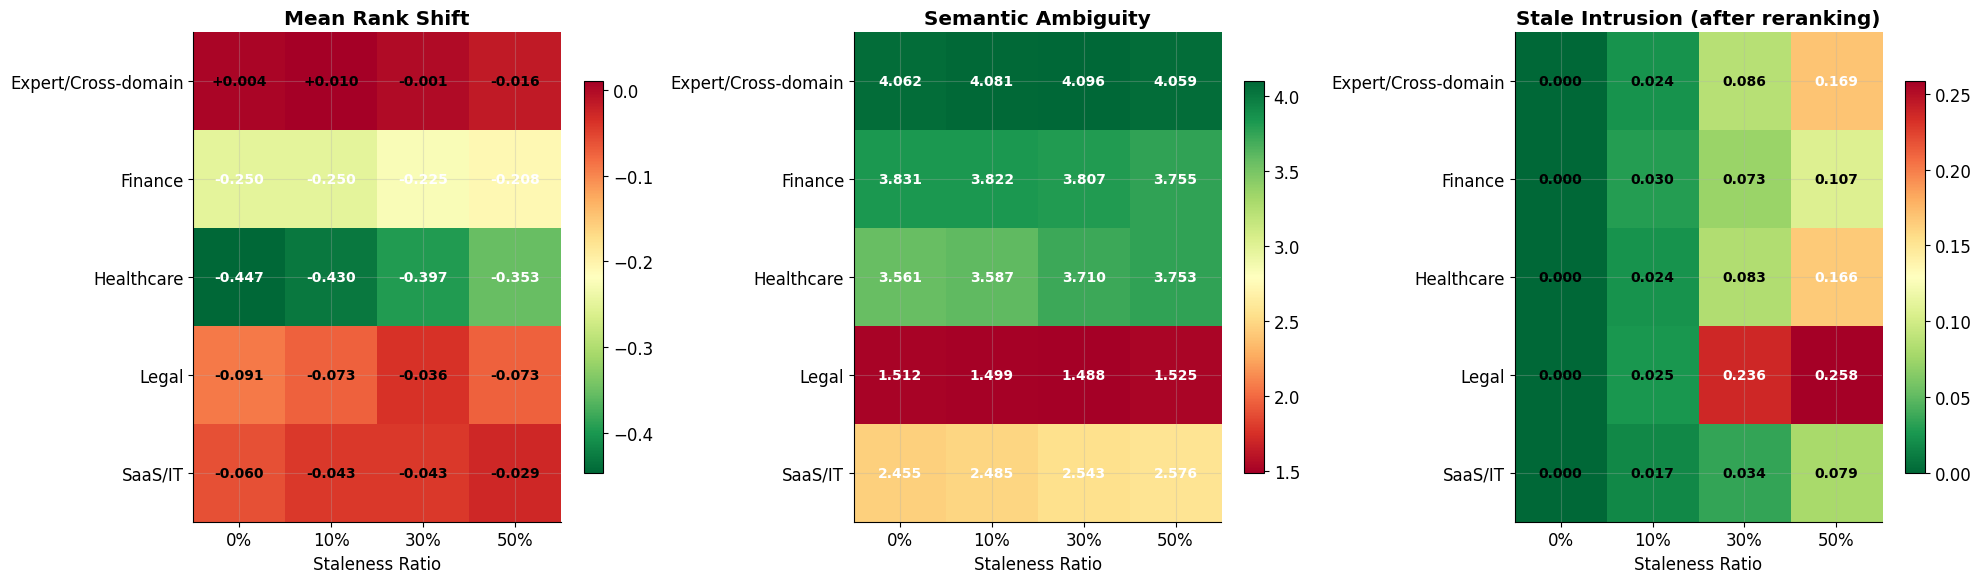

Saved: figures/fig13_rerank_domain_heatmap.png


In [15]:
# ── Fig 6: Domain heatmap ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

domain_metrics = [
    ('Mean Rank Shift', 'Mean Rank Shift', 'RdYlGn_r'),
    ('Semantic Ambiguity', 'Semantic Ambiguity', 'RdYlGn'),
    ('Stale Intrusion (after)', 'Stale Intrusion (after reranking)', 'RdYlGn_r'),
]

for ax, (metric, title, cmap) in zip(axes, domain_metrics):
    pivot = df_domain.pivot_table(index='Domain', columns='Staleness %', values=metric)
    pivot = pivot[[0, 10, 30, 50]]

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Staleness Ratio')
    ax.set_title(title, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(4):
            val = pivot.values[i, j]
            fmt = f'{val:+.3f}' if 'Rank' in metric else f'{val:.3f}'
            text_color = 'white' if abs(val) > 0.15 else 'black'
            ax.text(j, i, fmt, ha='center', va='center', fontsize=10, fontweight='bold', color=text_color)

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('../figures/fig13_rerank_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig13_rerank_domain_heatmap.png')

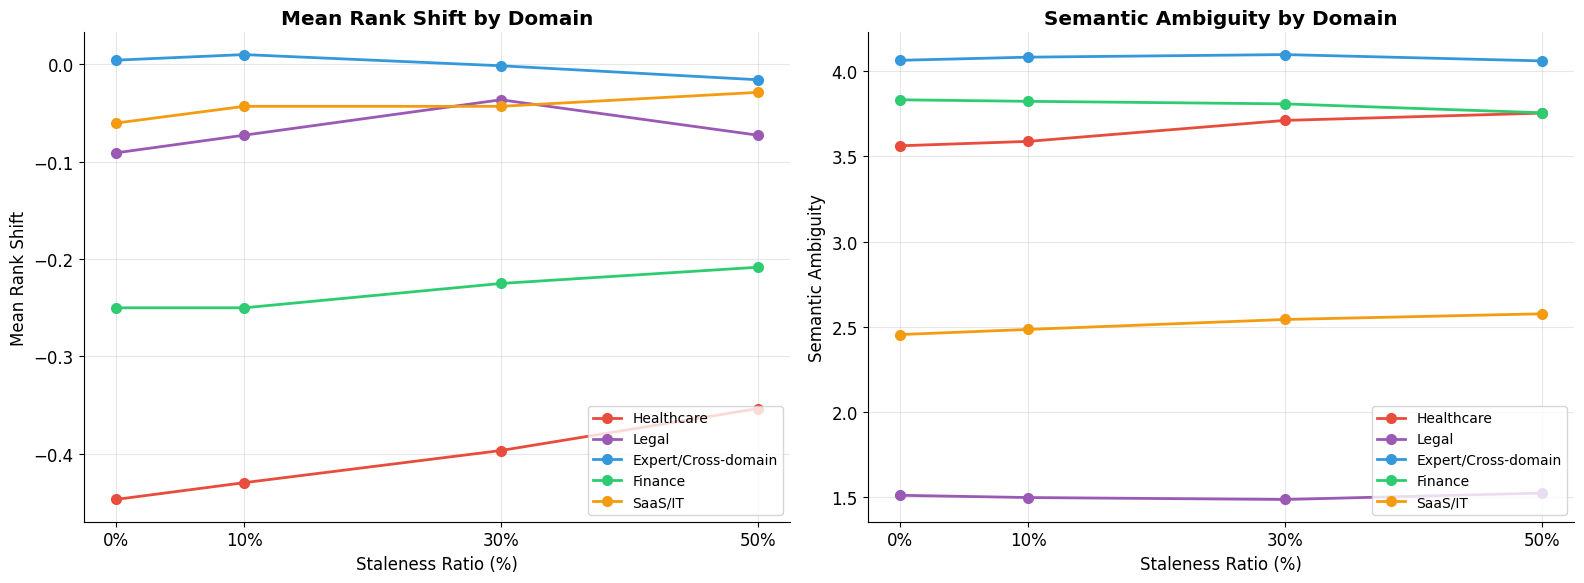

Saved: figures/fig14_rerank_domain_curves.png


In [16]:
# ── Fig 7: Domain degradation curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

domain_colors = {
    'Healthcare': '#e74c3c',
    'Legal': '#9b59b6',
    'Expert/Cross-domain': '#3498db',
    'Finance': '#2ecc71',
    'SaaS/IT': '#f39c12',
}

for ax, metric, title in zip(axes,
    ['Mean Rank Shift', 'Semantic Ambiguity'],
    ['Mean Rank Shift by Domain', 'Semantic Ambiguity by Domain']):
    for domain_label in DOMAIN_LABELS.values():
        subset = df_domain[df_domain['Domain'] == domain_label]
        ax.plot(subset['Staleness %'], subset[metric], '-o',
                label=domain_label, color=domain_colors.get(domain_label, '#333'),
                linewidth=2, markersize=7)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/fig14_rerank_domain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig14_rerank_domain_curves.png')

## 7. Stale Document Promotion
Does the cross-encoder actively promote stale documents to higher ranks?

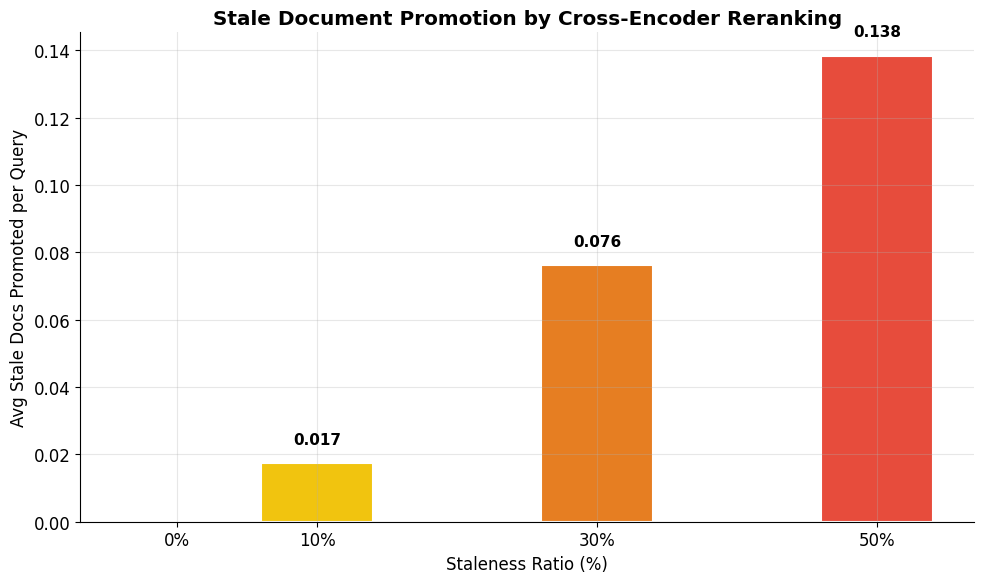

Saved: figures/fig15_stale_promotion.png


In [17]:
# ── Fig 8: Stale doc promotion ──
fig, ax = plt.subplots(figsize=(10, 6))

stale_prom = [data['overall'][c]['stale_promoted_mean'] for c in CONDITIONS]
colors = [COLORS[c] for c in CONDITIONS]

bars = ax.bar(STALENESS_PCTS, stale_prom, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Avg Stale Docs Promoted per Query')
ax.set_title('Stale Document Promotion by Cross-Encoder Reranking', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])

for bar, val in zip(bars, stale_prom):
    if val > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig15_stale_promotion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig15_stale_promotion.png')

## 8. Summary Statistics

In [18]:
# ── Key findings ──
fresh = data['overall']['fresh']
stale50 = data['overall']['stale_50']

print('=' * 60)
print('KEY FINDINGS — RERANKING STAGE')
print('=' * 60)

print(f'\n1. MEAN RANK SHIFT OF RELEVANT DOCUMENTS')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["mean_rank_shift_mean"]:+.4f} '
          f'(promoted: {d["relevant_promoted_mean"]:.2f}, demoted: {d["relevant_demoted_mean"]:.2f})')

print(f'\n2. SEMANTIC AMBIGUITY SCORE')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["semantic_ambiguity_score_mean"]:.4f} ± {d["semantic_ambiguity_score_std"]:.4f}')

print(f'\n3. LATENCY')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: inference={d["inference_time_ms_mean"]:.2f}ms, '
          f'total_rerank={d["total_rerank_latency_ms_mean"]:.2f}ms, '
          f'retrieval={d["retrieval_latency_ms_mean"]:.2f}ms')

print(f'\n4. PRECISION@k CHANGE (before → after reranking)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    before = d['original_precision_at_k_mean']
    after = d['reranked_precision_at_k_mean']
    delta = after - before
    pct = delta / before * 100 if before > 0 else 0
    print(f'   {CONDITION_LABELS[cond]:>12}: {before:.4f} → {after:.4f} ({delta:+.4f}, {pct:+.1f}%)')

print(f'\n5. STALE INTRUSION CHANGE (before → after reranking)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    before = d['original_stale_intrusion_rate_mean']
    after = d['reranked_stale_intrusion_rate_mean']
    delta = after - before
    print(f'   {CONDITION_LABELS[cond]:>12}: {before:.4f} → {after:.4f} ({delta:+.4f})')

print(f'\n6. STALE DOCUMENT PROMOTION')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["stale_promoted_mean"]:.3f} stale docs promoted/query')

KEY FINDINGS — RERANKING STAGE

1. MEAN RANK SHIFT OF RELEVANT DOCUMENTS
     Fresh (0%): -0.1701 (promoted: 0.37, demoted: 0.26)
      Stale 10%: -0.1586 (promoted: 0.35, demoted: 0.25)
      Stale 30%: -0.1422 (promoted: 0.34, demoted: 0.23)
      Stale 50%: -0.1370 (promoted: 0.33, demoted: 0.23)

2. SEMANTIC AMBIGUITY SCORE
     Fresh (0%): 3.1058 ± 1.9110
      Stale 10%: 3.1164 ± 1.9203
      Stale 30%: 3.1506 ± 1.9599
      Stale 50%: 3.1547 ± 1.9432

3. LATENCY
     Fresh (0%): inference=133.35ms, total_rerank=133.39ms, retrieval=36.70ms
      Stale 10%: inference=109.47ms, total_rerank=109.50ms, retrieval=13.00ms
      Stale 30%: inference=112.45ms, total_rerank=112.48ms, retrieval=13.12ms
      Stale 50%: inference=106.47ms, total_rerank=106.50ms, retrieval=14.20ms

4. PRECISION@k CHANGE (before → after reranking)
     Fresh (0%): 0.2401 → 0.2401 (+0.0000, +0.0%)
      Stale 10%: 0.2401 → 0.2401 (+0.0000, +0.0%)
      Stale 30%: 0.2367 → 0.2367 (+0.0000, +0.0%)
      Stale 50

In [19]:
# ── Export summary table ──
summary_df = df_overview[['Staleness %', 'Mean Rank Shift', 'Semantic Ambiguity',
                           'Inference Time (ms)', 'Total Rerank Latency (ms)',
                           'Precision@k (before)', 'Precision@k (after)',
                           'Stale Intrusion (before)', 'Stale Intrusion (after)']].copy()
summary_df.to_csv('../results/rerank_summary_table.csv')
print('Exported: results/rerank_summary_table.csv')
print()
print(summary_df.to_string(float_format='{:.4f}'.format))

Exported: results/rerank_summary_table.csv

            Staleness %  Mean Rank Shift  Semantic Ambiguity  Inference Time (ms)  Total Rerank Latency (ms)  Precision@k (before)  Precision@k (after)  Stale Intrusion (before)  Stale Intrusion (after)
Condition                                                                                                                                                                                                 
Fresh (0%)            0          -0.1701              3.1058             133.3465                   133.3873                0.2401               0.2401                    0.0000                   0.0000
Stale 10%            10          -0.1586              3.1164             109.4657                   109.4978                0.2401               0.2401                    0.0242                   0.0242
Stale 30%            30          -0.1422              3.1506             112.4504                   112.4838                0.2367              

## 9. Findings and Results

*This section will be populated after running the reranking evaluation.*

Key questions to answer:

- **Does reranking help or hurt?** Compare precision@k before vs. after across conditions.
- **Does the cross-encoder see through staleness?** If semantic ambiguity stays flat, the reranker falls into the same temporal-semantic trap as the bi-encoder.
- **Rank shift direction:** Negative mean rank shift = reranker promotes relevant docs. If this worsens with staleness, the reranker is actively harmed by outdated content.
- **Latency cost:** Is the cross-encoder inference overhead justified by quality gains?
- **Stale promotion:** Does the reranker actively promote stale documents to higher ranks, amplifying the contamination from Stage 3?